In [77]:
import time
import warnings
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.utils import resample
from sklearn.exceptions import ConvergenceWarning
from scipy.stats import uniform, randint, loguniform, t, sem
import tensorflow as tf
import keras_tuner as kt
from pyMAISE.datasets import load_MITR, load_chf

# Set display option to show all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Set the width of the columns
pd.set_option('display.width', None)

# See the full content of each column
pd.set_option('display.max_colwidth', None)

# Plot settings
matplotlib_settings = {
    "font.size": 12,
    "legend.fontsize": 11,
    "figure.figsize": (12, 8)
}
plt.rcParams.update(**matplotlib_settings)

# Suppress all ConvergenceWarnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)

print('libraries imported and settings configured')

libraries imported and settings configured


In [78]:
# load data

# Helper func for ensuring y is 2D
def ensure_2d_targets(y):
    y = np.asarray(y)
    if y.ndim == 1:
        return y.reshape(-1, 1)
    return y

# Multi-output
data, inputs, outputs = load_MITR()

# Single-output
# train_data, train_inputs, train_outputs = load_chf(data_path='datasets/chf_train_synth.csv')
# test_data, test_inputs, test_outputs = load_chf(data_path='datasets/chf_test_synth.csv')
# data = np.concat([train_data, test_data])
# inputs = np.asarray(np.concat([train_inputs, test_inputs]))
# outputs = ensure_2d_targets(np.concat([train_outputs, test_outputs]))

print(f'data shape: {data.shape}')
print(f'inputs shape: {inputs.shape}')
print(f'outputs shape: {outputs.shape}')
print('Data loaded')

data shape: (1000, 28)
inputs shape: (1000, 6)
outputs shape: (1000, 22)
Data loaded


In [79]:
# Data Bias: Create k-fold cv on train/test sets.
k = 2

kf = KFold(n_splits=k, shuffle=True, random_state=42)
X_train_sets = np.empty((k, (k-1)*inputs.shape[0] // k, inputs.shape[-1]))
X_test_sets = np.empty((k, inputs.shape[0] // k, inputs.shape[-1]))
Y_train_sets = np.empty((k, (k-1)*outputs.shape[0] // k, outputs.shape[-1]))
Y_test_sets = np.empty((k, outputs.shape[0] // k, outputs.shape[-1]))
print(X_train_sets.shape)
print(Y_train_sets.shape)
print(X_test_sets.shape)
print(Y_test_sets.shape)

for n, (train_index, test_index) in enumerate(kf.split(inputs)):
    X_train_sets[n] = inputs[train_index]
    X_test_sets[n] = inputs[test_index]
    Y_train_sets[n] = outputs[train_index]
    Y_test_sets[n] = outputs[test_index]

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("fnn", MLPRegressor(max_iter=10, random_state=42))
])

model = TransformedTargetRegressor(
    regressor=pipe,
    transformer=StandardScaler()
)

print('Data preprocessing completed')

(2, 500, 6)
(2, 500, 22)
(2, 500, 6)
(2, 500, 22)
Data preprocessing completed


In [80]:
# Model Bias: Define hyper parameter distributions for random search.
wide_layer_sizes = [
    (64,), (128,), (256,), (512,),
    (128, 128), (256, 256),
    (128, 64), (256, 128),
    (512, 256), (256, 128, 64),
]
narrow_layer_sizes = [
    (8,), (16,), (32,),
    (16, 8), (32, 16),
    (32, 16, 8), (16, 16),
    (24, 12), (12, 12, 12),
    (32, 24, 16),
]
taper_layer_sizes = [
    (256, 128, 64),
    (512, 256, 128),
    (256, 128, 64, 32),
    (128, 64, 32, 16),
    (512, 256, 128, 64),
    (256, 128, 64, 32, 16),
    (128, 96, 64, 32),
    (256, 192, 128, 64),
    (384, 256, 128),
    (192, 128, 64, 32),
]
rev_taper_layer_sizes = [
    (32, 64, 128),
    (64, 128, 256),
    (16, 32, 64, 128),
    (32, 64, 128, 256),
    (8, 16, 32, 64),
    (16, 32, 64, 128, 256),
    (24, 48, 96),
    (32, 96, 192),
    (64, 128, 256, 512),
    (32, 64, 128, 256, 512),
]
bowtie_layer_sizes = [
    (128, 32, 128),
    (256, 64, 256),
    (128, 64, 32, 64, 128),
    (256, 128, 64, 128, 256),
    (64, 16, 64),
    (128, 32, 16, 32, 128),
    (256, 64, 32, 64, 256),
    (192, 64, 192),
    (128, 48, 24, 48, 128),
    (256, 96, 48, 96, 256),
]

activation = ["relu", "tanh"]
alpha = loguniform(1e-5, 1e-1)
learning_rate_init = loguniform(1e-4, 1e-2)
solver = ["adam", 'lbfgs']
early_stopping = [True]
validation_fraction = [0.1]

n_iter = 5
scoring = "r2"
cv = 5
verbose = 1
random_state = 42
n_jobs = -1

wide_fnn_param_dist = {
    "regressor__fnn__hidden_layer_sizes": wide_layer_sizes,
    "regressor__fnn__activation": activation,
    "regressor__fnn__alpha": alpha,
    "regressor__fnn__learning_rate_init": learning_rate_init,
    "regressor__fnn__solver": solver,
    "regressor__fnn__early_stopping": early_stopping,
    "regressor__fnn__validation_fraction": validation_fraction,
}

narrow_fnn_param_dist = {
    "regressor__fnn__hidden_layer_sizes": narrow_layer_sizes,
    "regressor__fnn__activation": activation,
    "regressor__fnn__alpha": alpha,
    "regressor__fnn__learning_rate_init": learning_rate_init,
    "regressor__fnn__solver": solver,
    "regressor__fnn__early_stopping": early_stopping,
    "regressor__fnn__validation_fraction": validation_fraction,
}

taper_fnn_param_dist = {
    "regressor__fnn__hidden_layer_sizes": taper_layer_sizes,
    "regressor__fnn__activation": activation,
    "regressor__fnn__alpha": alpha,
    "regressor__fnn__learning_rate_init": learning_rate_init,
    "regressor__fnn__solver": solver,
    "regressor__fnn__early_stopping": early_stopping,
    "regressor__fnn__validation_fraction": validation_fraction,
}

rev_taper_fnn_param_dist = {
    "regressor__fnn__hidden_layer_sizes": rev_taper_layer_sizes,
    "regressor__fnn__activation": activation,
    "regressor__fnn__alpha": alpha,
    "regressor__fnn__learning_rate_init": learning_rate_init,
    "regressor__fnn__solver": solver,
    "regressor__fnn__early_stopping": early_stopping,
    "regressor__fnn__validation_fraction": validation_fraction,
}

bowtie_fnn_param_dist = {
    "regressor__fnn__hidden_layer_sizes": bowtie_layer_sizes,
    "regressor__fnn__activation": activation,
    "regressor__fnn__alpha": alpha, #regularization
    "regressor__fnn__learning_rate_init": learning_rate_init,
    "regressor__fnn__solver": solver,
    "regressor__fnn__early_stopping": early_stopping,
    "regressor__fnn__validation_fraction": validation_fraction,
}

wide_fnn_random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=wide_fnn_param_dist,
    n_iter=n_iter,
    scoring=scoring,
    cv=cv,
    verbose=verbose,
    random_state=random_state,
    n_jobs=n_jobs
)

narrow_fnn_random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=narrow_fnn_param_dist,
    n_iter=n_iter,
    scoring=scoring,
    cv=cv,
    verbose=verbose,
    random_state=random_state,
    n_jobs=n_jobs
)

taper_fnn_random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=taper_fnn_param_dist,
    n_iter=n_iter,
    scoring=scoring,
    cv=cv,
    verbose=verbose,
    random_state=random_state,
    n_jobs=n_jobs
)

rev_taper_fnn_random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=rev_taper_fnn_param_dist,
    n_iter=n_iter,
    scoring=scoring,
    cv=cv,
    verbose=verbose,
    random_state=random_state,
    n_jobs=n_jobs
)

bowtie_fnn_random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=bowtie_fnn_param_dist,
    n_iter=n_iter,
    scoring=scoring,
    cv=cv,
    verbose=verbose,
    random_state=random_state,
    n_jobs=n_jobs
)

print('Hyperparameter definitions completed')

Hyperparameter definitions completed


In [81]:
# Sampling Bias: Generate multiple training sets with different sampling methods.
def make_bootstrap_train_sets(X_train_sets, Y_train_sets, n_sets=5, random_state=42):
    X_boot_train_sets = np.empty(shape=(n_sets, X_train_sets.shape[0], X_train_sets.shape[1], X_train_sets.shape[2]))
    Y_boot_train_sets = np.empty(shape=(n_sets, Y_train_sets.shape[0], Y_train_sets.shape[1], Y_train_sets.shape[2]))
    for i in np.arange(X_train_sets.shape[0]):
        for j in np.arange(n_sets): # n bootstrap samples per train set
            X_boot, Y_boot = resample(
                X_train_sets[i],
                Y_train_sets[i],
                n_samples=X_train_sets.shape[1],
                replace=True,
                random_state=random_state
            )
            X_boot_train_sets[j, i] = X_boot
            Y_boot_train_sets[j, i] = Y_boot
    return X_boot_train_sets, Y_boot_train_sets

def make_strata(Y, n_bins=2):
    Y = np.asarray(Y)
    binned_outputs = []
    for i in np.arange(Y.shape[1]):
        target_col = Y[:, i]
        edges = np.quantile(
            target_col,
            np.linspace(0, 1, n_bins + 1)
        )
        edges = np.unique(edges)
        binned_col = np.digitize(
            target_col,
            edges[1:-1],
            right=True
        )
        binned_outputs.append(binned_col)
    binned_outputs = np.column_stack(binned_outputs)
    strata = np.array([
        '_'.join(map(str, row))
        for row in binned_outputs
    ])
    return strata
    
def make_stratified_bootstrap_train_sets(X_train_sets, Y_train_sets, n_sets=5, random_state=42):
    X_boot_stratified_train_sets = np.empty(shape=(n_sets, X_train_sets.shape[0], X_train_sets.shape[1], X_train_sets.shape[2]))
    Y_boot_stratified_train_sets = np.empty(shape=(n_sets, Y_train_sets.shape[0], Y_train_sets.shape[1], Y_train_sets.shape[2]))
    for i in np.arange(X_train_sets.shape[0]):
        for j in np.arange(n_sets):
            X_boot_stratified, Y_boot_stratified = resample(
                X_train_sets[i], 
                Y_train_sets[i], 
                replace=True,
                n_samples=X_train_sets.shape[1],
                stratify=make_strata(Y_train_sets[i]),
                random_state=random_state
            )
            X_boot_stratified_train_sets[j, i] = X_boot_stratified
            Y_boot_stratified_train_sets[j, i] = Y_boot_stratified
    return X_boot_stratified_train_sets, Y_boot_stratified_train_sets

print('Sampling functions defined')

Sampling functions defined


In [82]:
# Generate new train sets with different sampling methods 
n_sets = 1
X_bootstrap_train_sets, Y_bootstrap_train_sets = make_bootstrap_train_sets(X_train_sets, Y_train_sets, n_sets=n_sets)
X_stratified_train_sets, Y_stratified_train_sets = make_stratified_bootstrap_train_sets(X_train_sets, Y_train_sets, n_sets=n_sets)

print(X_train_sets.shape, Y_train_sets.shape)
print(X_bootstrap_train_sets.shape, Y_bootstrap_train_sets.shape)
print(X_stratified_train_sets.shape, Y_stratified_train_sets.shape)

train_sets = []
for i in np.arange(X_train_sets.shape[0]):
    train_sets.append({
        'set_index': i,
        'sampling_method': 'none',
        'X_train_set': X_train_sets[i],
        'Y_train_set': Y_train_sets[i],
    })
for i in np.arange(X_bootstrap_train_sets.shape[0]):
    for j in np.arange(X_bootstrap_train_sets.shape[1]):
        train_sets.append({
            'set_index': j,
            'sampling_method': 'bootstrap',
            'X_train_set': X_bootstrap_train_sets[i, j],
            'Y_train_set': Y_bootstrap_train_sets[i, j],
        })
for i in np.arange(X_stratified_train_sets.shape[0]):
    for j in np.arange(X_stratified_train_sets.shape[1]):
        train_sets.append({
            'set_index': j,
            'sampling_method': 'stratified',
            'X_train_set': X_stratified_train_sets[i, j],
            'Y_train_set': Y_stratified_train_sets[i, j],
        })
train_sets = pd.DataFrame(train_sets)

print(train_sets.shape)

print('Sampled train sets created')

(2, 500, 6) (2, 500, 22)
(1, 2, 500, 6) (1, 2, 500, 22)
(1, 2, 500, 6) (1, 2, 500, 22)
(6, 4)
Sampled train sets created


In [83]:
def train_and_predict(random_search, train_sets, X_test_sets, architecture):
    print('-'*40)
    print(f'Starting model training for {architecture} architecture')
    print('-'*40)
    predictions = []
    for index, train_set in train_sets.iterrows():
        print(f'Training on set {index} out of {train_sets.shape[0]}')
        Y_train = ensure_2d_targets(train_set['Y_train_set'])
        fit_y = Y_train.ravel() if Y_train.shape[1] == 1 else Y_train
        random_search.fit(train_set['X_train_set'], fit_y)
        Y_pred = random_search.predict(X_test_sets[train_set['set_index']])
        Y_pred = ensure_2d_targets(Y_pred)
        for i in np.arange(Y_pred.shape[0]):
            for j in np.arange(Y_pred.shape[1]):
                predictions.append({
                    'train_test_set_index': train_set['set_index'],
                    'architecture': architecture,
                    'sampling_method': train_set['sampling_method'],
                    'sample_index': i,
                    'output_index': j,
                    'prediction': Y_pred[i, j]
                })
    return pd.DataFrame(predictions)

def get_scores_from_pred_df(pred_df, Y_test_sets):
    scores = []
    group_cols = ['architecture', 'sampling_method', 'train_test_set_index']
    for (architecture, sampling_method, set_index), group in pred_df.groupby(group_cols):
        Y_pred = (
            group
            .pivot(index='sample_index', columns='output_index', values='prediction')
            .sort_index(axis=0)
            .sort_index(axis=1)
            .to_numpy()
        )
        Y_true = ensure_2d_targets(Y_test_sets[set_index])
        scores.append({
            'set_index': set_index,
            'architecture': architecture,
            'sampling_method': sampling_method,
            'r2': r2_score(Y_true, Y_pred),
            'mae': mean_absolute_error(Y_true, Y_pred),
            'rmse': root_mean_squared_error(Y_true, Y_pred),
        })
    return pd.DataFrame(scores)

def get_uq_results_from_pred_df(pred_df):
    results = []
    group_cols = ['architecture', 'sampling_method', 'train_test_set_index']
    for (architecture, sampling_method, set_index), group in pred_df.groupby(group_cols):
        Y_pred = (
            group
            .pivot(index='sample_index', columns='output_index', values='prediction')
            .sort_index(axis=0)
            .sort_index(axis=1)
            .to_numpy()
        )
        means = np.mean(Y_pred, axis=0)
        variances = np.var(Y_pred, axis=0)
        stds = np.std(Y_pred, axis=0)
        sems = sem(Y_pred, axis=0)
        n = Y_pred.shape[0]
        c_intervals_lower = means - sems * t.ppf(1.95 / 2.0, n-1)
        c_intervals_upper = means + sems * t.ppf(1.95 / 2.0, n-1)
        for output_index in np.arange(Y_pred.shape[1]):
            results.append({
                'train_test_set_index': set_index,
                'architecture': architecture,
                'sampling_method': sampling_method,
                'output_index': output_index,
                'mean': means[output_index],
                'variances': variances[output_index],
                'std': stds[output_index],
                '95_ci_lower': c_intervals_lower[output_index],
                '95_ci_upper': c_intervals_upper[output_index],
            })
    return pd.DataFrame(results)

print('Data analysis functions defined')

Data analysis functions defined


In [84]:
# Train models and get predictions
wide_pred_df = train_and_predict(wide_fnn_random_search, train_sets, X_test_sets, 'wide')
narrow_pred_df = train_and_predict(narrow_fnn_random_search, train_sets, X_test_sets, 'narrow')
taper_pred_df = train_and_predict(taper_fnn_random_search, train_sets, X_test_sets, 'taper')
rev_taper_pred_df = train_and_predict(rev_taper_fnn_random_search, train_sets, X_test_sets, 'rev_taper')
bowtie_pred_df = train_and_predict(bowtie_fnn_random_search, train_sets, X_test_sets, 'bowtie')
pred_df = pd.concat([
    wide_pred_df,
    narrow_pred_df,
    taper_pred_df,
    rev_taper_pred_df,
    bowtie_pred_df
])

print('All models trained')

----------------------------------------
Starting model training for wide architecture
----------------------------------------
Training on set 0 out of 6
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Training on set 1 out of 6
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Training on set 2 out of 6
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Training on set 3 out of 6
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Training on set 4 out of 6
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Training on set 5 out of 6
Fitting 5 folds for each of 5 candidates, totalling 25 fits
----------------------------------------
Starting model training for narrow architecture
----------------------------------------
Training on set 0 out of 6
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Training on set 1 out of 6
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Training on set 2 out of 6
Fitting 5 folds for

In [85]:
uq_results_df = get_uq_results_from_pred_df(pred_df)
uq_results_df.head()

,train_test_set_index,architecture,sampling_method,output_index,mean,variances,std,95_ci_lower,95_ci_upper
0,0,bowtie,bootstrap,0,25855.910855,12123.479639,110.106674,25846.226602,25865.595108
1,0,bowtie,bootstrap,1,22752.084398,19262.888058,138.790807,22739.877279,22764.291517
2,0,bowtie,bootstrap,2,21574.645606,22771.481646,150.902225,21561.373247,21587.917964
3,0,bowtie,bootstrap,3,22827.824598,15374.373931,123.993443,22816.918958,22838.730239
4,0,bowtie,bootstrap,4,21852.613065,17278.982051,131.449542,21841.051635,21864.174494


(330000, 6)


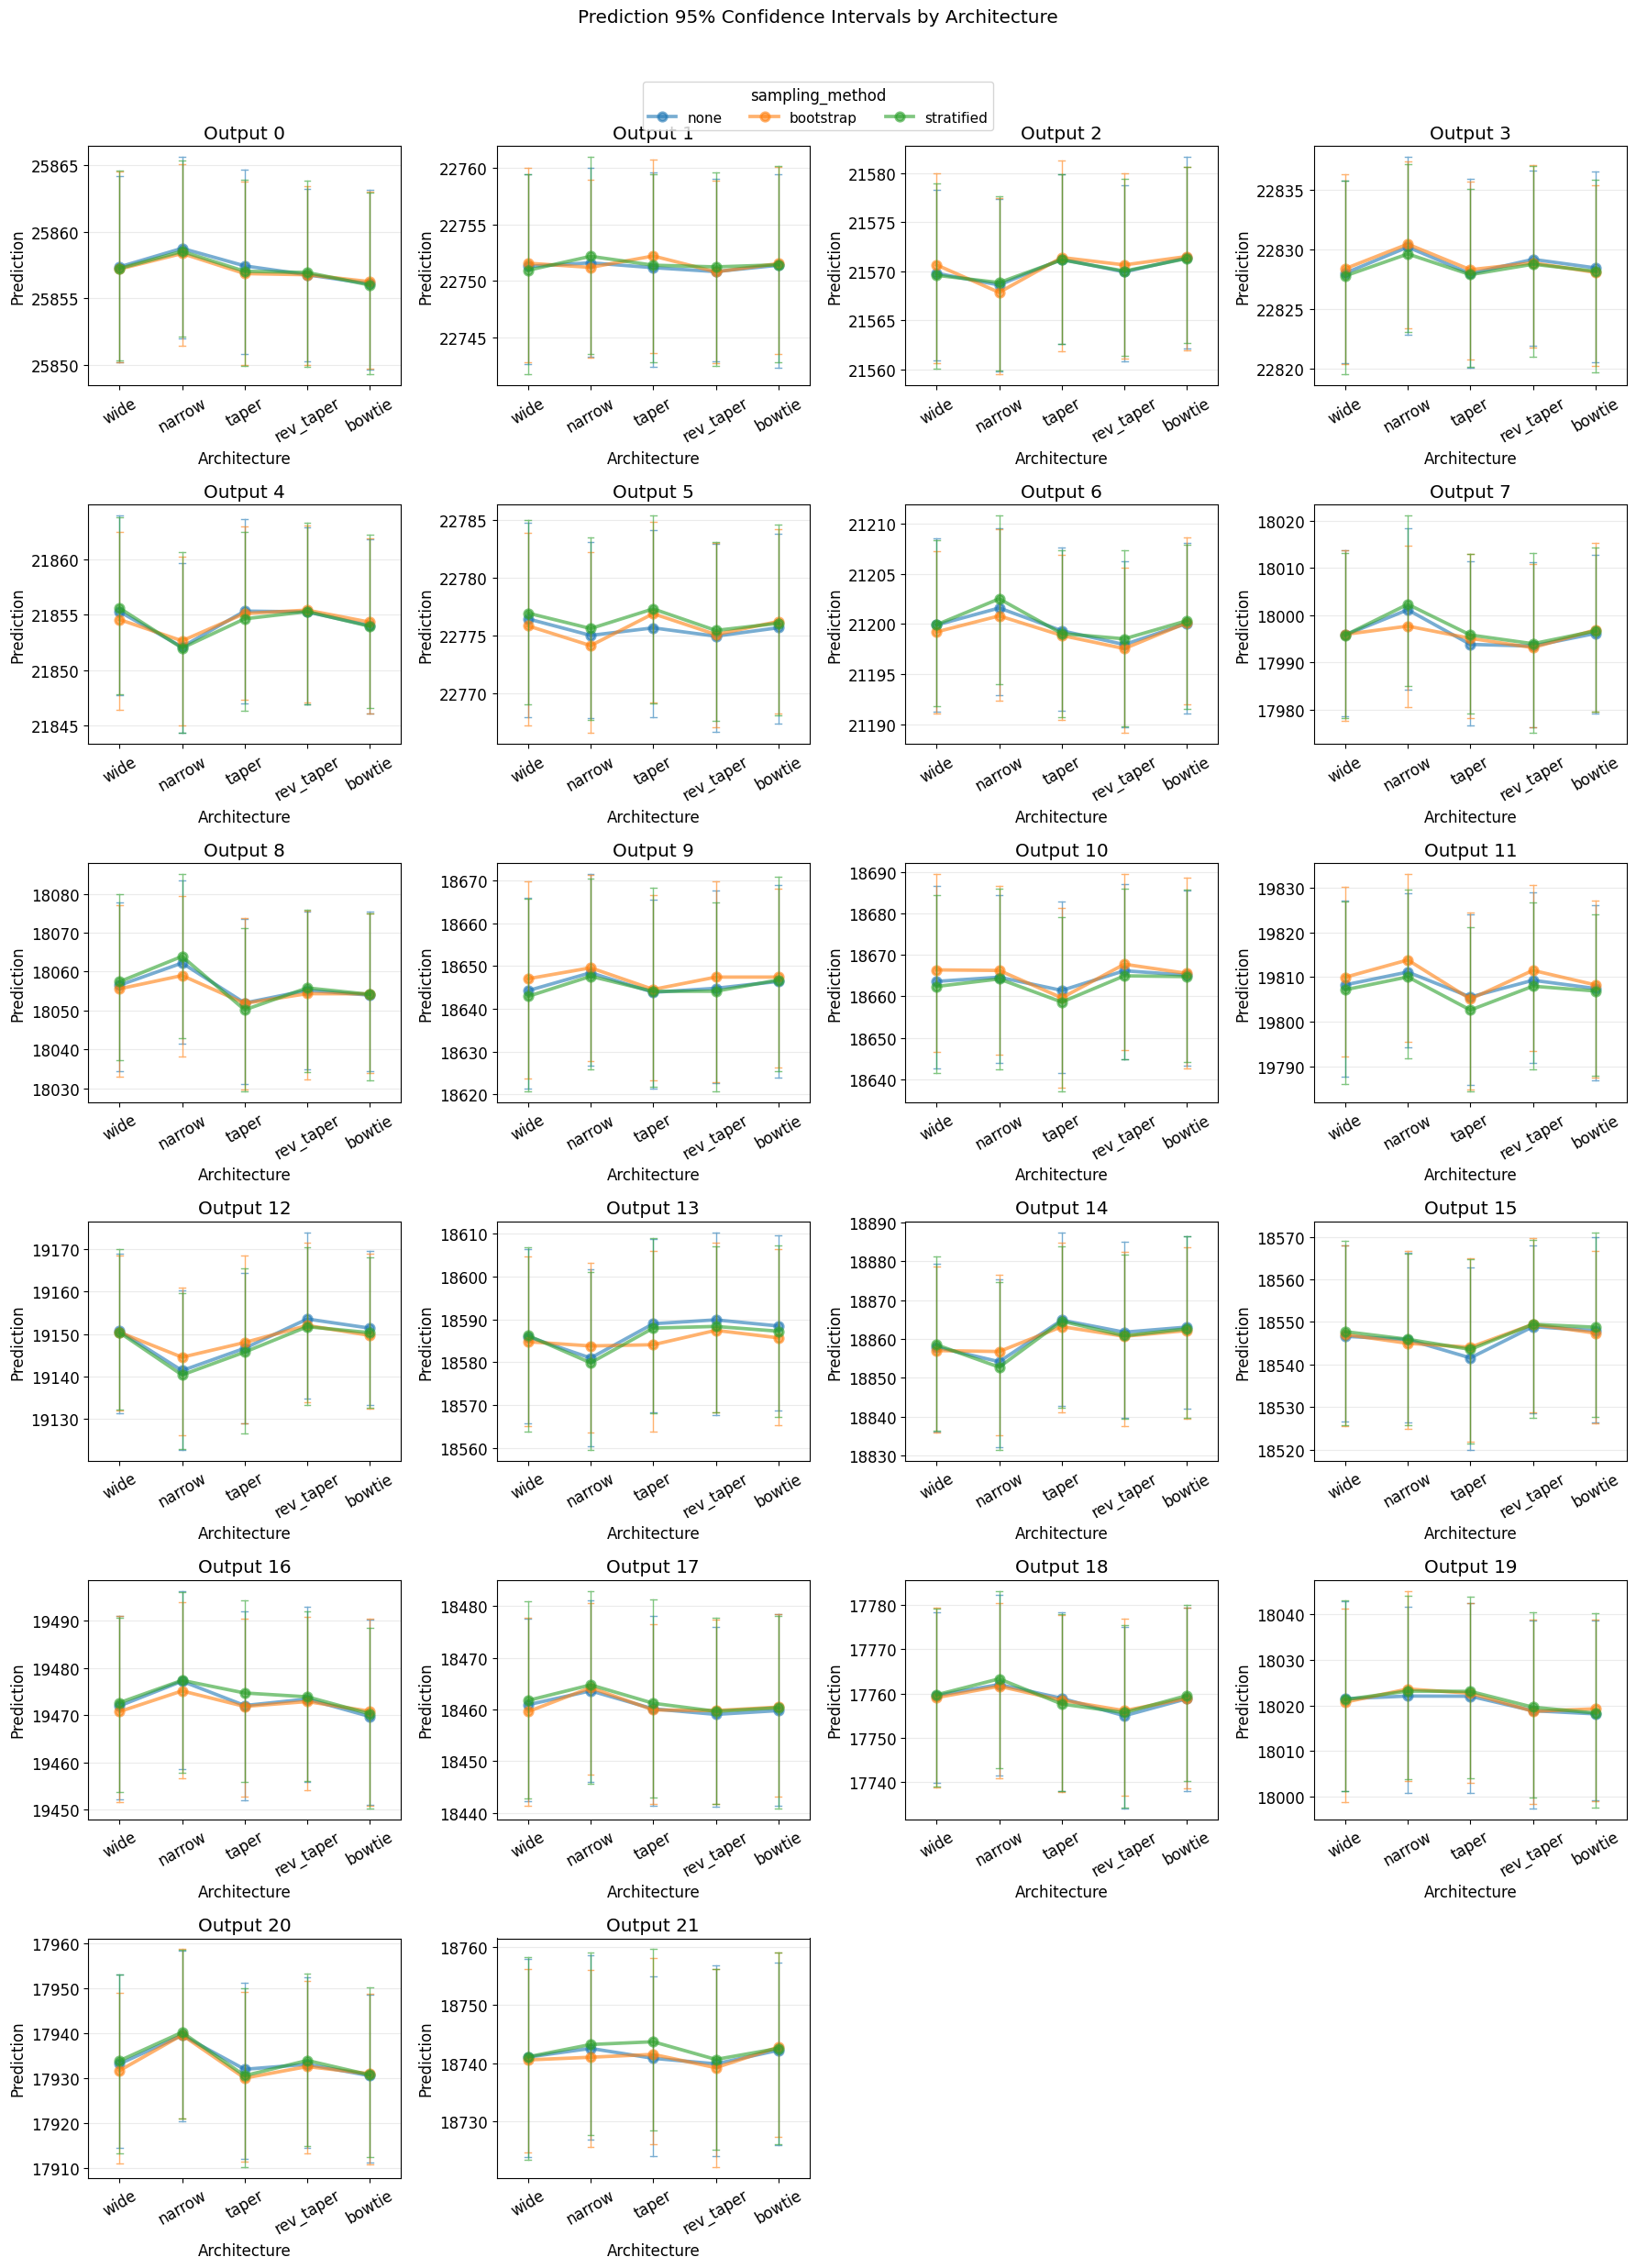

In [86]:
# Use seaborn to show each output index on its own subplot with confidence intervals.
print(pred_df.shape)

def plot_predictions_by_output(pred_df, output_indices=None, n_cols=4):
    if output_indices is None:
        output_indices = sorted(pred_df['output_index'].unique())

    n_outputs = len(output_indices)
    n_rows = int(np.ceil(n_outputs / n_cols))
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.5 * n_cols, 4 * n_rows),
        squeeze=False
    )
    axes = axes.flatten()
    legend_handles = None
    legend_labels = None

    for ax, output_index in zip(axes, output_indices):
        output_pred_df = pred_df[pred_df['output_index'] == output_index]

        sns.pointplot(
            data=output_pred_df,
            x='architecture',
            y='prediction',
            hue='sampling_method',
            alpha=0.6,
            estimator='mean',
            errorbar=('ci', 95),
            err_kws={'linewidth': 1},
            capsize=0.1,
            markers='o',
            linestyles='-',
            ax=ax
        )
        ax.set_title(f'Output {output_index}')
        ax.set_xlabel('Architecture')
        ax.set_ylabel('Prediction')
        ax.tick_params(axis='x', rotation=30)
        ax.grid(axis='y', alpha=0.25)

        if ax.get_legend() is not None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()
            ax.get_legend().remove()

    for ax in axes[n_outputs:]:
        ax.set_visible(False)

    if legend_handles is not None:
        fig.legend(
            legend_handles,
            legend_labels,
            title='sampling_method',
            loc='upper center',
            ncol=len(legend_labels),
            bbox_to_anchor=(0.5, 1.0)
        )

    fig.suptitle('Prediction 95% Confidence Intervals by Architecture', y=1.03)
    plt.tight_layout()
    plt.show()

plot_predictions_by_output(pred_df)

In [87]:
scores_df = get_scores_from_pred_df(pred_df, Y_test_sets)
scores_df.head()

,set_index,architecture,sampling_method,r2,mae,rmse
0,0,bowtie,bootstrap,0.991781,17.928178,23.509772
1,1,bowtie,bootstrap,0.990012,19.236003,25.740191
2,0,bowtie,none,0.991963,17.756052,23.261165
3,1,bowtie,none,0.990410,18.850156,25.164204
4,0,bowtie,stratified,0.992103,17.632989,23.023935


(30, 6)


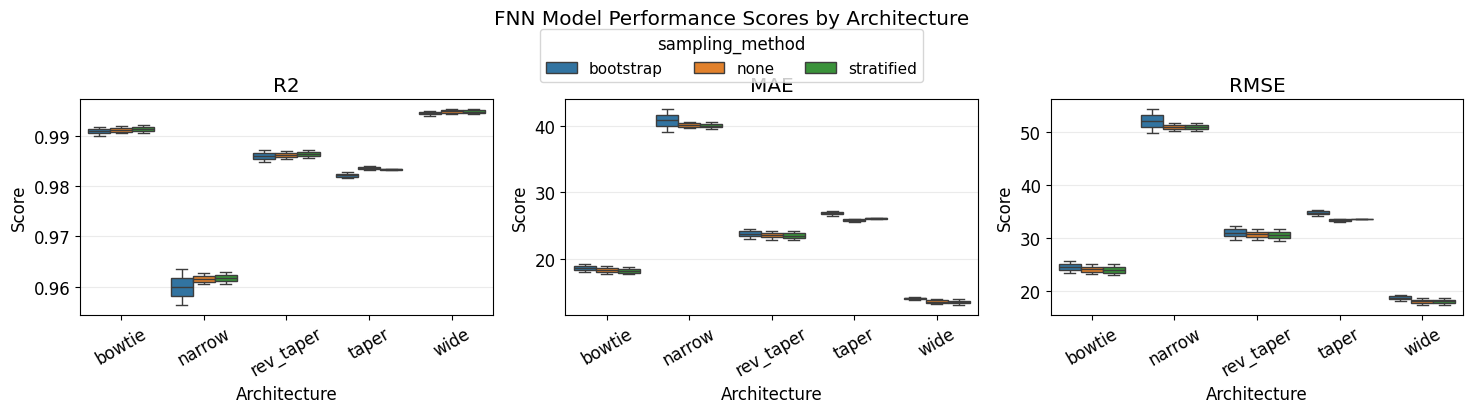

In [88]:
# Compare performance scores for trained FNN models.
print(scores_df.shape)

def plot_scores_by_metric(scores_df, score_cols=None, n_cols=3):
    if score_cols is None:
        score_cols = ['r2', 'mae', 'rmse']

    n_scores = len(score_cols)
    n_rows = int(np.ceil(n_scores / n_cols))
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5 * n_cols, 4 * n_rows),
        squeeze=False
    )
    axes = axes.flatten()
    legend_handles = None
    legend_labels = None

    for ax, score_col in zip(axes, score_cols):
        sns.boxplot(
            data=scores_df,
            x='architecture',
            y=score_col,
            hue='sampling_method',
            ax=ax
        )
        ax.set_title(score_col.upper())
        ax.set_xlabel('Architecture')
        ax.set_ylabel('Score')
        ax.tick_params(axis='x', rotation=30)
        ax.grid(axis='y', alpha=0.25)

        if ax.get_legend() is not None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()
            ax.get_legend().remove()

    for ax in axes[n_scores:]:
        ax.set_visible(False)

    if legend_handles is not None:
        fig.legend(
            legend_handles,
            legend_labels,
            title='sampling_method',
            loc='upper center',
            ncol=len(legend_labels),
            bbox_to_anchor=(0.5, 1.0)
        )

    fig.suptitle('FNN Model Performance Scores by Architecture', y=1.03)
    plt.tight_layout()
    plt.show()

plot_scores_by_metric(scores_df)


(330000, 6)


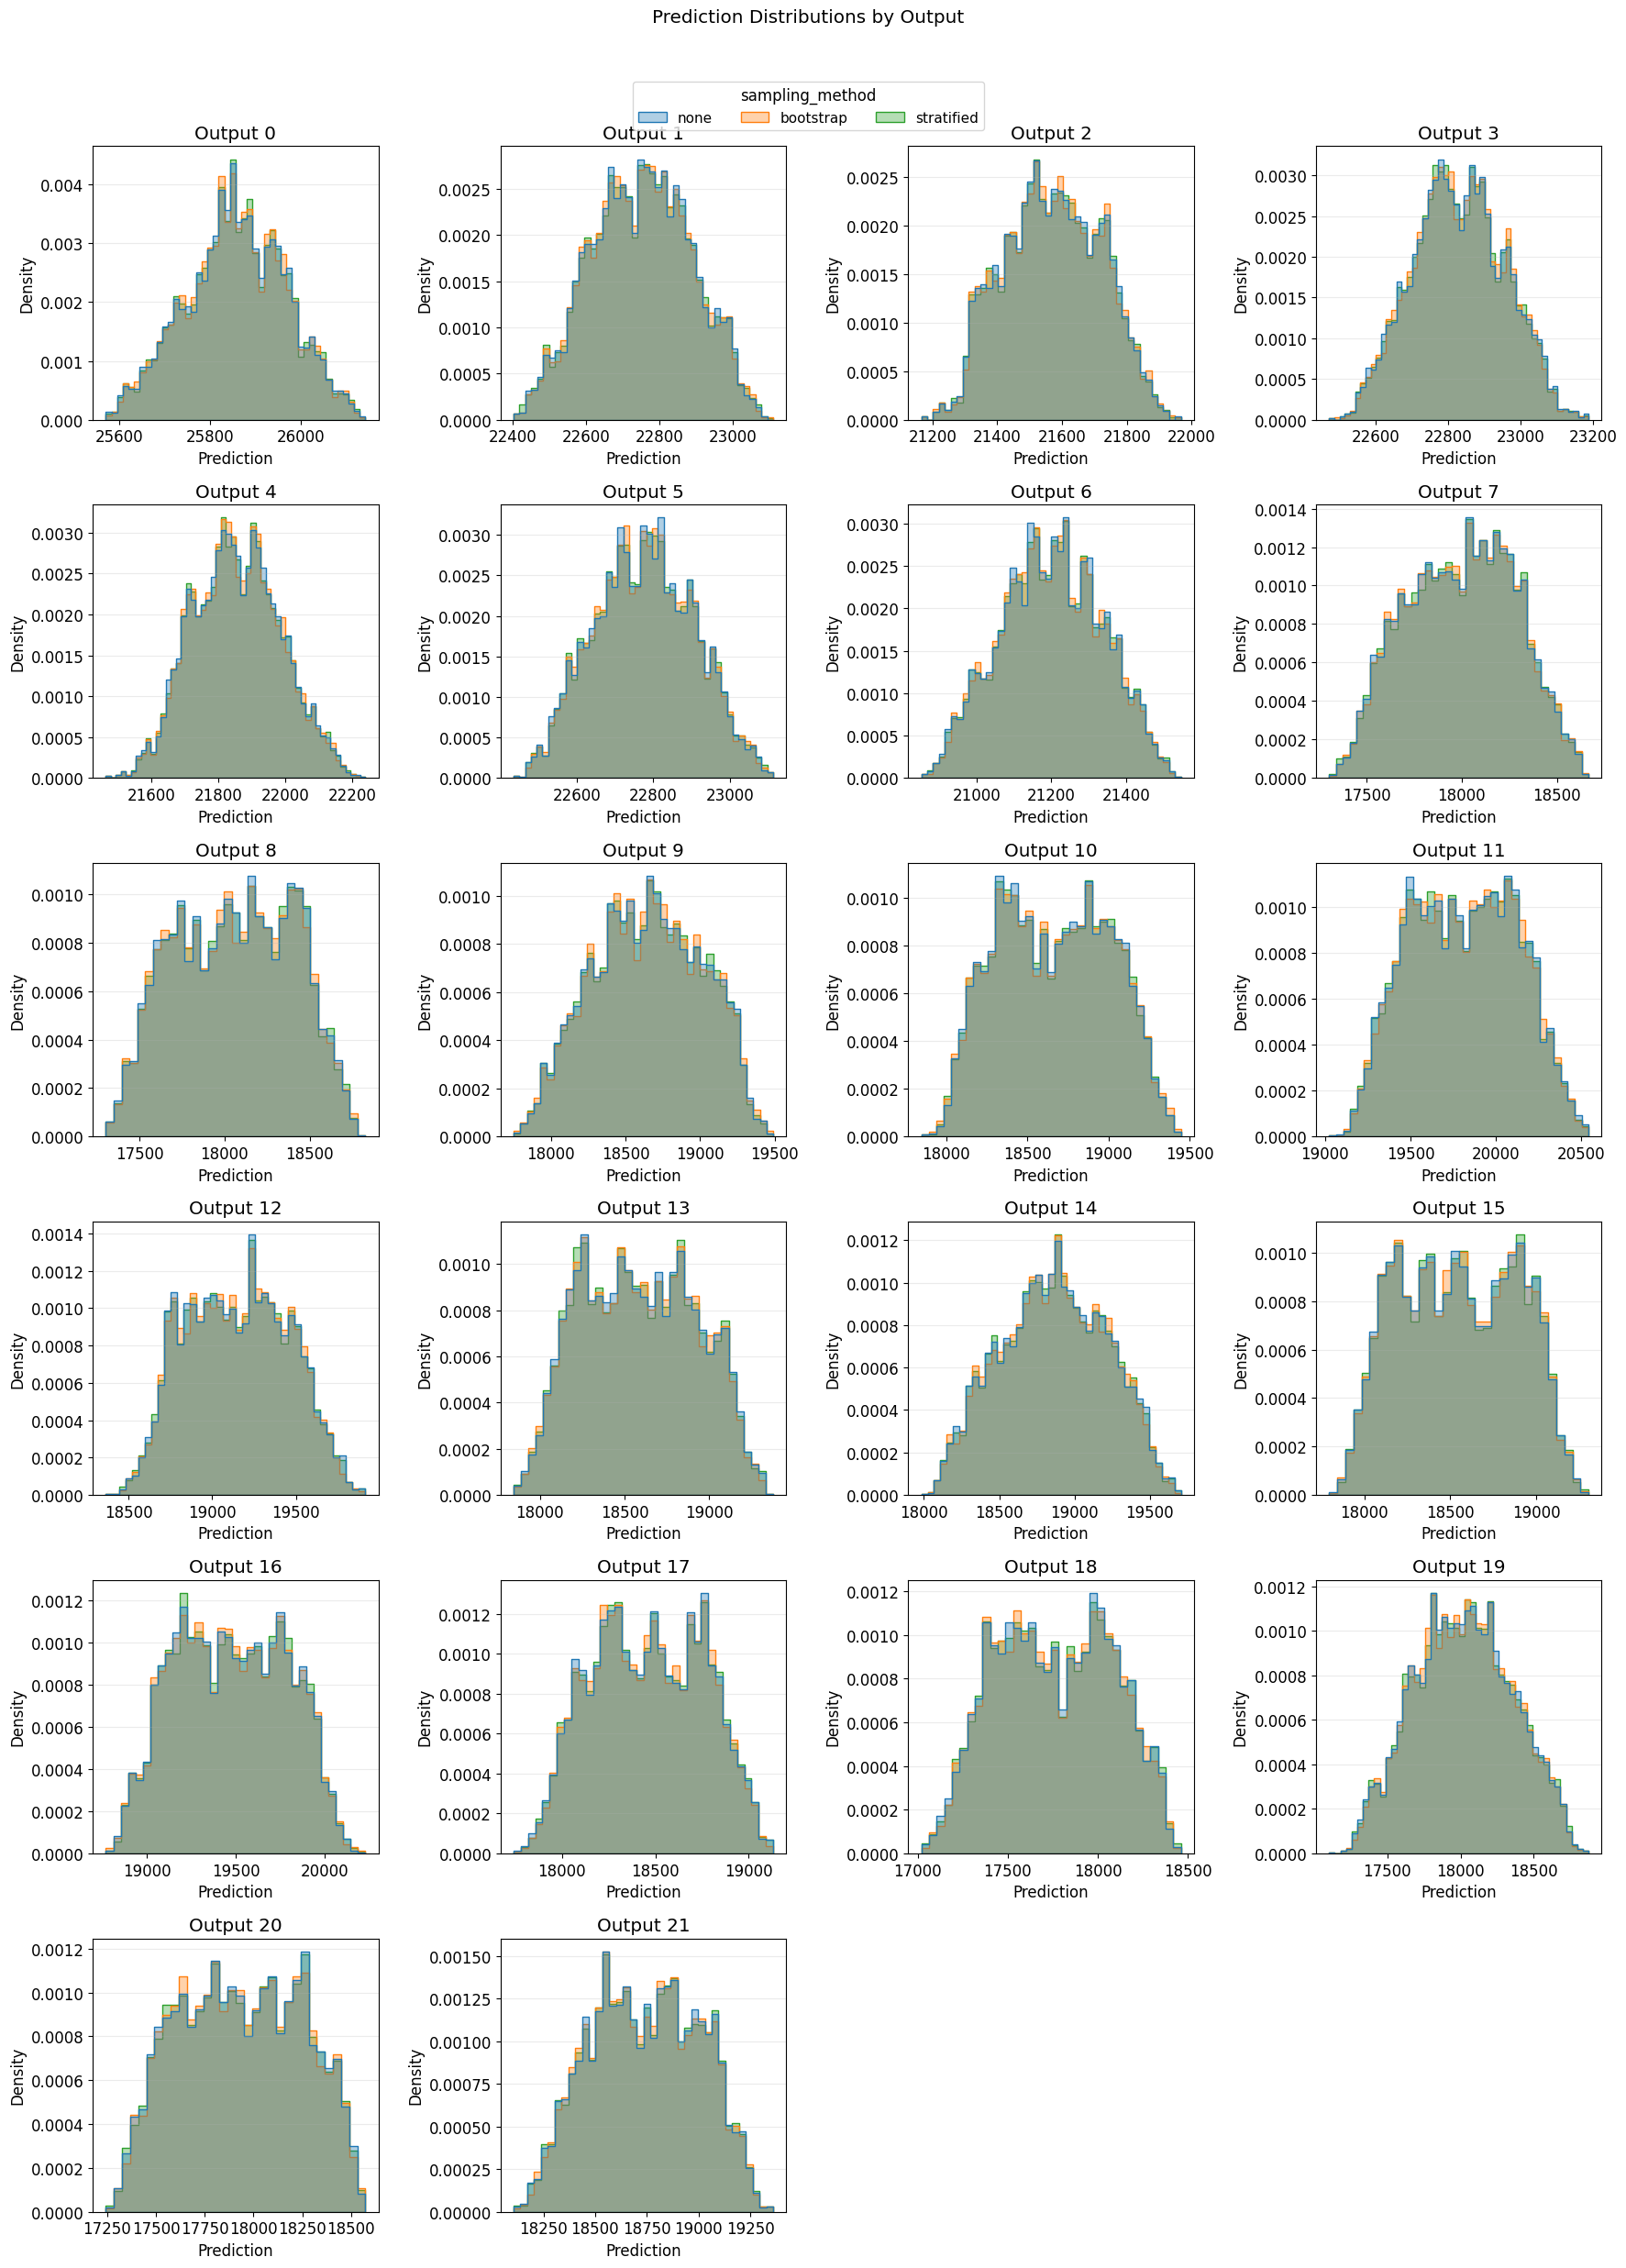

In [89]:
# Show prediction distributions for each output index.
print(pred_df.shape)

def plot_prediction_distributions_by_output(pred_df, output_indices=None, n_cols=4):
    if output_indices is None:
        output_indices = sorted(pred_df['output_index'].unique())

    n_outputs = len(output_indices)
    n_rows = int(np.ceil(n_outputs / n_cols))
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.5 * n_cols, 4 * n_rows),
        squeeze=False
    )
    axes = axes.flatten()
    legend_handles = None
    legend_labels = None

    for ax, output_index in zip(axes, output_indices):
        output_pred_df = pred_df[pred_df['output_index'] == output_index]

        sns.histplot(
            data=output_pred_df,
            x='prediction',
            hue='sampling_method',
            element='step',
            stat='density',
            common_norm=False,
            alpha=0.35,
            ax=ax
        )
        ax.set_title(f'Output {output_index}')
        ax.set_xlabel('Prediction')
        ax.set_ylabel('Density')
        ax.grid(axis='y', alpha=0.25)

        if ax.get_legend() is not None:
            legend = ax.get_legend()
            legend_handles = legend.legend_handles
            legend_labels = [text.get_text() for text in legend.get_texts()]
            legend.remove()

    for ax in axes[n_outputs:]:
        ax.set_visible(False)

    if legend_handles is not None:
        fig.legend(
            legend_handles,
            legend_labels,
            title='sampling_method',
            loc='upper center',
            ncol=len(legend_labels),
            bbox_to_anchor=(0.5, 1.0)
        )

    fig.suptitle('Prediction Distributions by Output', y=1.03)
    plt.tight_layout()
    plt.show()

plot_prediction_distributions_by_output(pred_df)
